In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [32]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.datasets import load_diabetes

In [14]:
X,y = load_diabetes(return_X_y = True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)



In [15]:
print(f"Shape of x is {X_train.shape}")
print(f"Shape of y is {y_train.shape}")

Shape of x is (353, 10)
Shape of y is (353,)


In [16]:
class LinReg:
    def __init__(self,alpha=0.01,iters=10000):
        # initialise parameters the algorithm will use
        self.alpha = alpha
        self.iters = iters
        self.w = None
        self.b = None
        self.J_history = []

    def compute_cost(self,X,y,y_hat):
        m,n = X.shape
        return (1/(2*m))*(np.sum((y_hat-y)**2))
        

    def fit(self,X,y):
        # Fit the paramters for the training set
        m,n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        y = y.reshape(-1) # Scikit learn requirement

        for i in range(self.iters):
            # Cost Function is 1/2m*(sum(h(xi)-yi)**2)
            y_hat = X@(self.w)+(self.b)

            # Gradients
            dJ_dw = (1/m)*np.dot(X.T,(y_hat-y))
            dJ_db = (1/m)*np.sum(y_hat-y)

            # Paramaters Update
            self.w-=(self.alpha)*(dJ_dw)
            self.b-=(self.alpha)*(dJ_db)

            if i%100 == 0:
                self.J_history.append(self.compute_cost(X,y,y_hat))
        
    def predict(self,X):
        return X@(self.w)+(self.b)
        

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid",palette="muted")

In [44]:
model = LinReg(alpha=0.01,iters=10000)
model.fit(X_train,y_train)

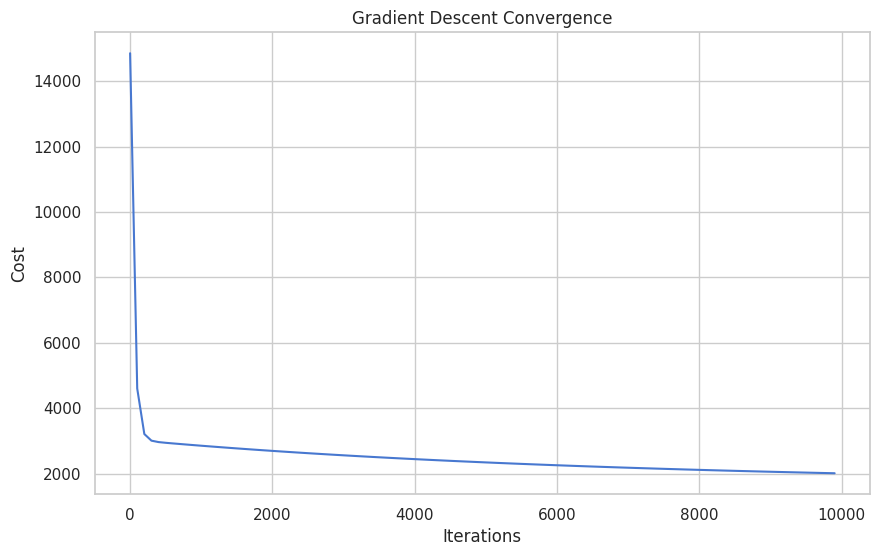

In [47]:
plt.figure(figsize=(10,6))
history = pd.DataFrame({
    "Iterations":range(0,len(model.J_history)*100,100),
    "Cost":model.J_history
})
sns.lineplot(data=history,x="Iterations",y="Cost",color="b")
plt.title('Gradient Descent Convergence')
plt.show()